In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft
import time

1) b)

In [33]:
def f(x):
    return np.exp(-50*(x-0.5)**2)

#Discrete Fourier Transform
def DFT(x):
    N = len(x)
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        for n in range(N):
            X[k] += x[n] * np.exp(-2j*np.pi*k*n/N)
    return X

#Inverse Discrete Fourier Transform
def IDFT(X):
    N = len(X)
    x = np.zeros(N, dtype=complex)
    for n in range(N):
        for k in range(N):
            x[n] += X[k] * np.exp(2j*np.pi*k*n/N)
    return x / N

#Analytical Fourier Transform
def fhat_analytic(k):
    return np.sqrt(np.pi/50)*np.exp(-k**2/200)*np.exp(-1j*k/2)

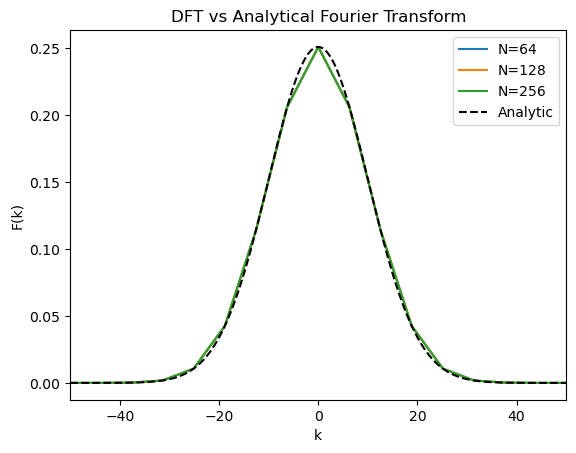

In [36]:
Ns = [64, 128, 256]
x_dense = np.linspace(0, 1, 2000)

plt.figure()

for N in Ns:
    x = np.linspace(0, 1, N, endpoint = False)
    fx = f(x)
    Xk = DFT(fx) * (1/N)
    
    k = 2*np.pi*np.fft.fftfreq(N, d=1/N)
    idx = np.argsort(k)
    
    plt.plot(k[idx], np.abs(Xk[idx]), label=f"N={N}")
    
k_plot = np.linspace(-50, 50, 1000)
plt.plot(k_plot, np.abs(fhat_analytic(k_plot)), 'k--', label="Analytic")

plt.xlim(-50, 50)
plt.xlabel("k")
plt.ylabel("F(k)")
plt.legend()
plt.title("DFT vs Analytical Fourier Transform")
plt.show()

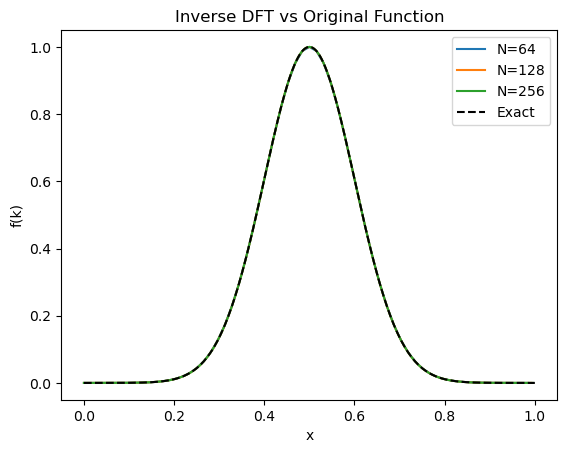

In [32]:
plt.figure()

for N in Ns:
    x = np.linspace(0, 1, N, endpoint = False)
    fx = f(x)
    fx_rec = IDFT(DFT(fx)).real
    plt.plot(x, fx_rec, label = f"N={N}")

plt.plot(x_dense, f(x_dense), 'k--', label = "Exact")
plt.xlabel("x")
plt.ylabel("f(k)")
plt.legend()
plt.title("Inverse DFT vs Original Function")
plt.show()

1) c)

In [42]:
def time_DFT(N, runs = 100):
    x = np.linspace(0, 1, N, endpoint = False)
    fx = f(x)
    start = time.time()
    for _ in range(runs):
        DFT(fx)
    return (time.time() - start) / runs

def time_FFT(N, runs = 100):
    x = np.linspace(0, 1, N, endpoint = False)
    fx = f(x)
    start = time.time()
    for _ in range (runs):
        np.fft.fft(fx)
    return (time.time() - start) / runs

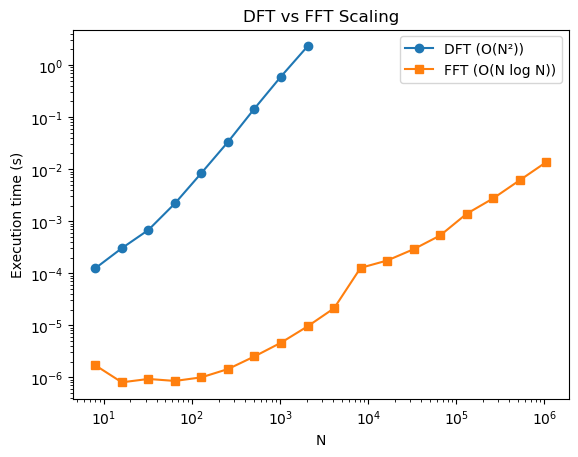

In [43]:
Ns_DFT = [2**j for j in range(3, 12)]
Ns_FFT = [2**j for j in range(3, 21)]

t_DFT = [time_DFT(N) for N in Ns_DFT]
t_FFT = [time_FFT(N) for N in Ns_FFT]

plt.figure()
plt.loglog(Ns_DFT, t_DFT, 'o-', label = "DFT (O(N²))")
plt.loglog(Ns_FFT, t_FFT, 's-', label="FFT (O(N log N))")
plt.xlabel("N")
plt.ylabel("Execution time (s)")
plt.legend()
plt.title("DFT vs FFT Scaling")
plt.show()

2) a)

In [44]:
N = 256
alpha = 0.005
dt = 0.001
T = 5
steps = int(T / dt)

x = np.linspace(0, 1, N, endpoint = False)
dx = 1 / N

#k-grid
k = 2 * np.pi * np.fft.fftfreq(N, d = dx)

u0 = np.exp(-50 * (x - 0.5) ** 2)
u_hat = DFT(u0)

In [ ]:
u_hat